# Hierarchical Risk Parity (HRP

Perché HRP batte Markowitz (Mean-Variance)
Il problema fondamentale dell'approccio Mean-Variance (Markowitz) che abbiamo visto prima è matematico: richiede l'inversione della matrice di covarianza.
Quando gli asset sono altamente correlati (come accade spesso tra ETF azionari durante i cali di mercato), la matrice diventa "mal condizionata". Questo significa che piccoli errori di stima nei rendimenti o nelle correlazioni generano pesi del portafoglio assurdi (posizioni enormi long/short). Markowitz scambia il segnale per rumore.

[*********************100%***********************]  7 of 7 completed

--- Pesi Ottimali HRP ---
IEF     60.96%
GLD     15.38%
EWJ      7.20%
SPY      5.87%
VGK      5.59%
AAXJ     2.52%
EEM      2.49%
dtype: object

Volatilità Attesa (Annua): 6.98%


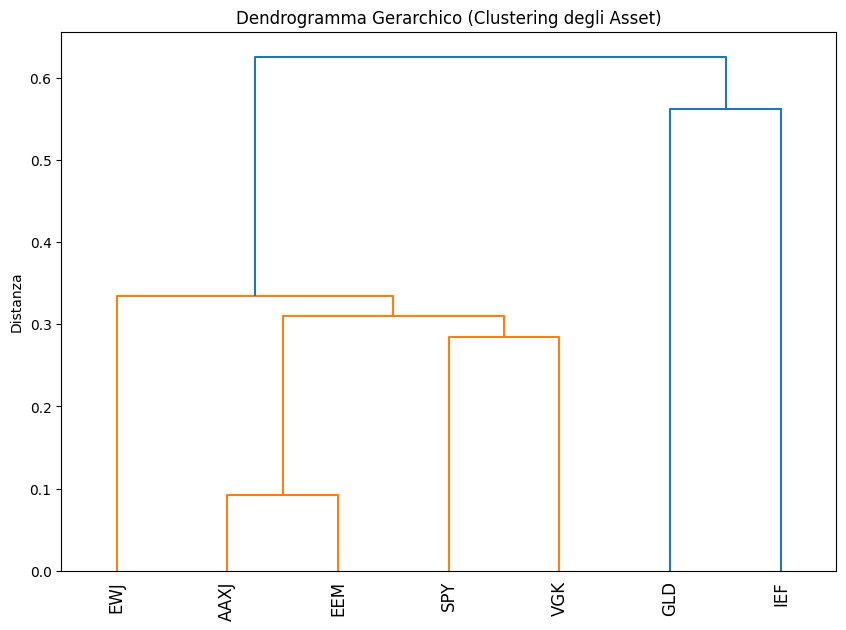

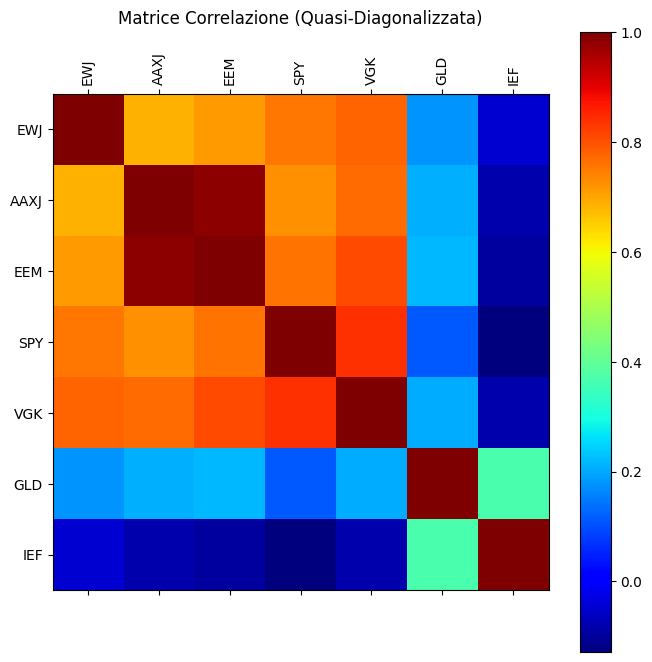

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. Preparazione Dati (Versione Robust)
tickers = ['SPY', 'VGK', 'EWJ', 'EEM', 'AAXJ', 'IEF', 'GLD']
start_date = '2018-01-01'
end_date = '2024-12-31'

# Scarichiamo i dati con auto_adjust=True
# Questo aggrega i dividendi/split direttamente nella colonna 'Close'
df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Gestione MultiIndex: estraiamo solo i prezzi di chiusura
if isinstance(df.columns, pd.MultiIndex):
    data = df['Close']
else:
    data = df[['Close']]

# Verifica se ci sono ticker mancanti o dati vuoti
if data.empty:
    raise ValueError("Errore nel download: il DataFrame è vuoto. Controlla la connessione o i ticker.")

returns = data.pct_change().dropna()

# 2. Funzioni Core HRP (Logica Quantitativa)

def getIVP(cov, **kargs):
    # Calcola l'Inverse Variance Portfolio (Portafoglio a inv. varianza)
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def getClusterVar(cov, cItems):
    # Calcola la varianza di un cluster (gruppo di asset)
    cov_slice = cov.loc[cItems, cItems] # sottomatrice
    w = getIVP(cov_slice).reshape(-1, 1)
    cVar = np.dot(np.dot(w.T, cov_slice), w)[0, 0]
    return cVar

def getQuasiDiag(link):
    # Riordina gli indici della matrice covarianza basandosi sul clustering
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3] # numero di items originali
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2) # make space
        df0 = sortIx[sortIx >= numItems] # find clusters
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0] # item 1
        df0 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df0]) # item 2
        sortIx = sortIx.sort_index()
        sortIx.index = range(sortIx.shape[0]) # re-index
    return sortIx.tolist()

def getRecBipart(cov, sortIx):
    # Allocazione Ricorsiva (Bisezione)
    # Inizializziamo esplicitamente come float64 per evitare FutureWarning
    w = pd.Series(1.0, index=sortIx)
    cItems = [sortIx] # inizializza con tutti gli item

    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(cItems), 2):
            cItems0 = cItems[i] # Cluster Sinistro
            cItems1 = cItems[i + 1] # Cluster Destro
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)

            # Calcolo del fattore di allocazione basato sulla varianza inversa dei cluster
            # alpha = 1 - (V0 / (V0 + V1))
            alpha = 1 - cVar0 / (cVar0 + cVar1)

            w[cItems0] *= alpha     # peso al cluster sinistro
            w[cItems1] *= 1 - alpha # peso al cluster destro
    return w

# 3. Esecuzione dell'Algoritmo

# A. Matrice di Correlazione e Covarianza
cov = returns.cov()
corr = returns.corr()

# B. Distanza basata sulla correlazione
# Distanza d(x,y) = sqrt(0.5 * (1 - rho(x,y)))
dist = np.sqrt((1 - corr) / 2)

# C. Clustering Gerarchico (Linkage Matrix)
# Usiamo il metodo 'single' linkage che è standard per HRP
dist_array = sch.distance.squareform(dist.values) # trasforma in array condensato per scipy
link = sch.linkage(dist_array, 'single')

# D. Quasi-Diagonalizzazione (Ordinamento)
sortIx = getQuasiDiag(link)
sortIx = corr.index[sortIx].tolist() # recupera i nomi dei ticker
df0 = corr.loc[sortIx, sortIx] # Matrice riordinata (solo per visualizzazione/check)

# E. Allocazione Pesi (Recursive Bisection)
hrp_weights = getRecBipart(cov, sortIx)
hrp_weights = hrp_weights.sort_index() # Rimettiamo in ordine alfabetico per lettura

# 4. Output e Visualizzazione Dendrogramma

print("--- Pesi Ottimali HRP ---")
print(hrp_weights.sort_values(ascending=False).apply(lambda x: f"{x:.2%}"))

# Calcolo volatilità del portafoglio HRP (ex-ante)
# var_p = w' * Sigma * w
hrp_vol = np.sqrt(np.dot(hrp_weights.T, np.dot(cov * 252, hrp_weights)))
print(f"\nVolatilità Attesa (Annua): {hrp_vol:.2%}")

# Visualizzazione Dendrogramma
plt.figure(figsize=(10, 7))
dn = sch.dendrogram(link, labels=returns.columns, leaf_rotation=90)
plt.title('Dendrogramma Gerarchico (Clustering degli Asset)')
plt.ylabel('Distanza')
plt.show()

# Visualizzazione Matrice Correlazione Riordinata (Quasi-Diagonal)
plt.figure(figsize=(8, 8))
plt.matshow(df0, fignum=1, cmap='jet')
plt.colorbar()
plt.xticks(range(len(df0.columns)), df0.columns, rotation=90)
plt.yticks(range(len(df0.columns)), df0.columns)
plt.title('Matrice Correlazione (Quasi-Diagonalizzata)', pad=20)
plt.show()